# 30 April 2026
- notebook to compare raw numbers of CV populations
- comparing Scaringi 1kpc pop from earth to thiele gxy DWD 
- questions
    - how many DWDs are in 150 pc / space density comparions
    - occupation fraction argument: how many CVs vs DWDs are in each LISA freq bin

In [19]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'  # LSS to avoid OOM errors when using jax in this script
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import legwork as lw
import astropy.coordinates as cc
import astropy.units as u
import healpy as hp
import sys
sys.path.append('../scripts/')
import paths
import h5py
import astropy.coordinates as apyco
import pickle as pkl
from CV_pop_create_fullgxy import galactic_positions, sample_fullgxy_population

import json
plt.rcParams.update(plt.rcParamsDefault)
with open('/home/levis/ng15_rcparams.json', 'rb') as fin:
    plt.rcParams.update(json.load(fin))
plt.style.use('seaborn-v0_8-colorblind')

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


- load populations (thiele+21 resampled to MW galactic positions)

In [3]:
cvthin = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/CV_fullgxy/rseed2035_thin/dat_fullgxy_thin_rs2035_final.txt')
cvthinemgap = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/CV_fullgxy/rseed2035_thin/dat_fullgxy_emgap_rs2035_nsamp1.0e+06_final.txt')

cvthick = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/CV_fullgxy/rseed2035_thick/dat_fullgxy_thick_rs2035_final.txt')
cvthickemgap = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/CV_fullgxy/rseed2035_thick/dat_fullgxy_emgap_rs2035_nsamp1.0e+06_final.txt')

file = '/home/levis/lisa_projects/blip_CVs/datasets/dwd_datasets/resampled_keepnearby_McMillan_galaxy_Thiele_fiducial_Z.hdf'
dwdrsamp = pd.read_hdf(file)


## Looking at difference in numbers between thick and thin gxy populations

In [3]:
cvthin.columns

Index(['# m1[Msun]', ' m2[Msun]', ' f_gw[Hz]', ' inclination[rad]',
       ' x_galcent[kpc]', ' y_galcent[kpc]', ' z_galcent[kpc]',
       ' Scar_reassigned', ' Pala_reassigned', ' dist_from_sun[kpc]'],
      dtype='object')

In [4]:
cvthick.shape[0] + cvthickemgap.shape[0]

4452411

In [5]:
cvthin.shape[0] + cvthinemgap.shape[0]

2648908

In [6]:
ssbary = apyco.SkyCoord(0*u.kpc, 0*u.kpc, 0*u.kpc, frame='barycentricmeanecliptic', representation_type='cartesian')
ssbary_galcen = ssbary.transform_to(apyco.Galactocentric)


In [7]:
ssbary_galcen.x.to(u.kpc)

<Quantity -8.12197337 kpc>

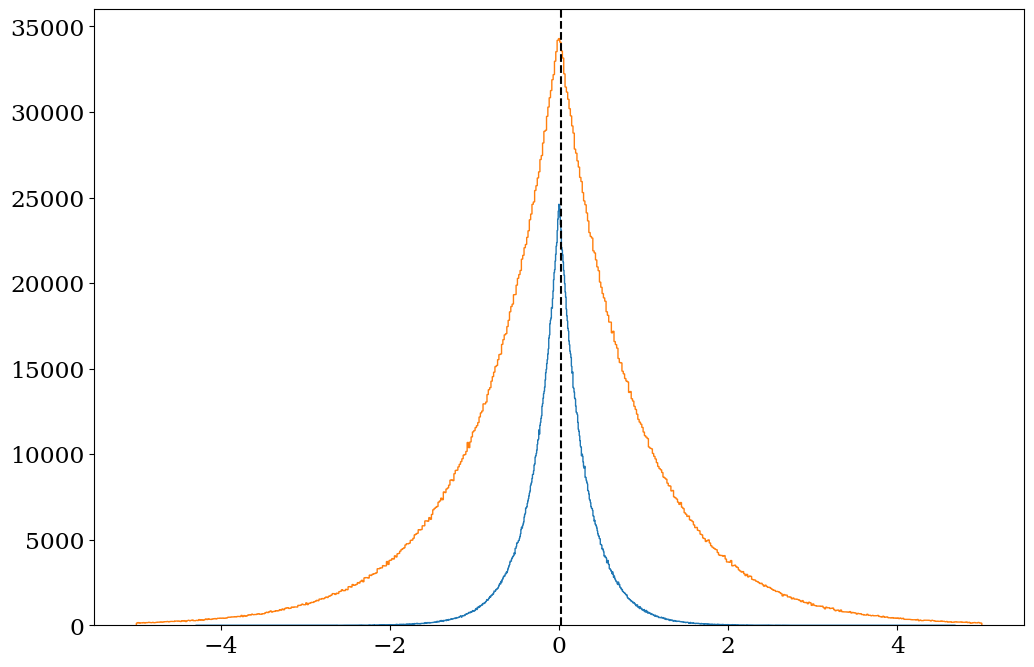

In [8]:
plt.hist(cvthin[' z_galcent[kpc]'], bins='auto', histtype='step');
plt.hist(cvthick[' z_galcent[kpc]'], bins='auto', histtype='step');
plt.axvline(ssbary_galcen.z.to(u.kpc).value, color='k', ls='--');

In [9]:
overdraw = int(5e6)
rseed = 2035
rngen = np.random.default_rng(rseed)
thinpos = galactic_positions(overdraw, rng=rngen,model="McMillan_fixed", disk='thin')
thickpos = galactic_positions(overdraw, rng=rngen,model="McMillan_fixed", disk='thick')

In [10]:
thinpos = np.array(thinpos)
thickpos = np.array(thickpos)

In [11]:
xthin, ythin, zthin = thinpos[0, :], thinpos[1, :], thinpos[2, :]
xthick, ythick, zthick = thickpos[0, :], thickpos[1, :], thickpos[2, :]

In [12]:
thinco = apyco.SkyCoord(x=xthin*u.kpc, y=ythin*u.kpc, z=zthin*u.kpc, frame='galactocentric', representation_type='cartesian')
thickco = apyco.SkyCoord(x=xthick*u.kpc, y=ythick*u.kpc, z=zthick*u.kpc, frame='galactocentric', representation_type='cartesian')
thincoSSBc = thinco.transform_to(apyco.BarycentricMeanEcliptic)
thickcoSSBc = thickco.transform_to(apyco.BarycentricMeanEcliptic)
dist_from_sun_thin = thincoSSBc.distance.to(u.kpc).value
dist_from_sun_thick = thickcoSSBc.distance.to(u.kpc).value

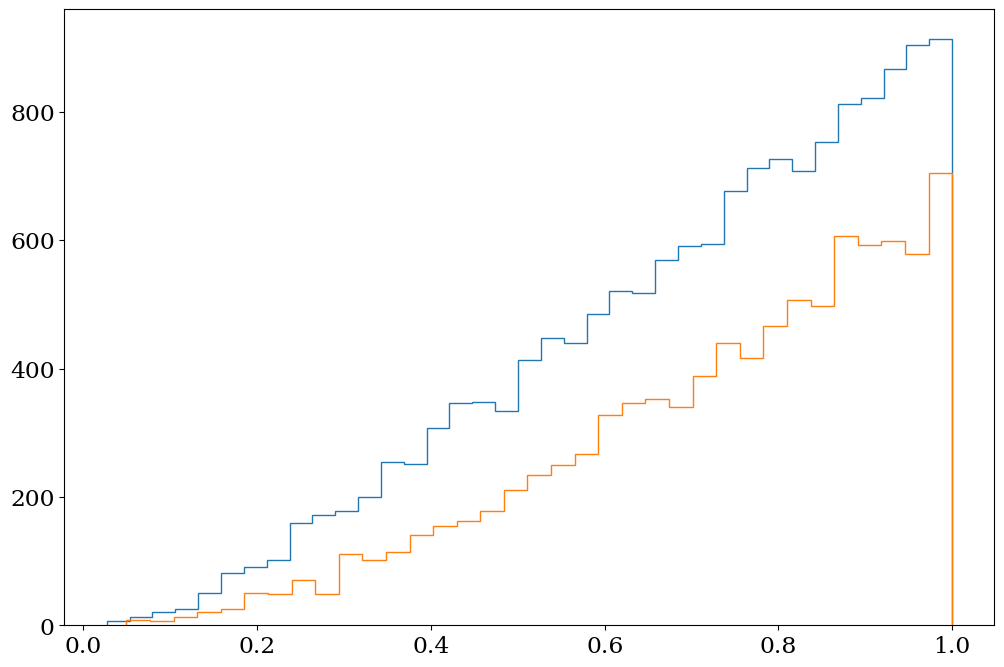

In [13]:
plt.hist(dist_from_sun_thin[dist_from_sun_thin<1], bins='auto', histtype='step');
plt.hist(dist_from_sun_thick[dist_from_sun_thick<1], bins='auto', histtype='step');

In [14]:
thinkpc = dist_from_sun_thin[dist_from_sun_thin<1].shape[0]
thickkpc = dist_from_sun_thick[dist_from_sun_thick<1].shape[0]

In [15]:
normfact_thin = 7284 / thinkpc
normfact_thick = 7284 / thickkpc

In [16]:
downsampthin = overdraw*normfact_thin
downsampthick = overdraw*normfact_thick
print(downsampthin, downsampthick)
print(downsampthin-downsampthick)

2363093.6932260576 3883971.4194305213
-1520877.7262044637


In [21]:
np.abs(downsampthin-downsampthick) / downsampthin

np.float64(0.643596032846326)

In [17]:
mu_m1 = 0.7
sigma_m1 = 0.001
sigma_m2 = 0.001
disc = 'thin'
rseed = 2035
rngen = np.random.default_rng(rseed)

thinpop = sample_fullgxy_population(mu_m1, sigma_m1, sigma_m2, rngen, disk=disc)

Drawing galactic positions...
Not enough sources within 1 kpc, redrawing population...
Drawing galactic positions...
Not enough sources within 1 kpc, redrawing population...
Drawing galactic positions...
Not enough sources within 1 kpc, redrawing population...
Number of sources within 1 kpc after downsampling: 7331
Difference between draw and Scaringi 1kpc pop after downsampling: 47
This is a 0.65% difference.


/home/levis/lisa_projects/blip_CVs/notebooks/../scripts/CV_pop_create_fullgxy.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  lpdist = pd.read_csv(paths.data / "lpdist3.out", delim_whitespace=True, header=None, names=['logp', 'CDF'])


7331 sources within 1 kpc available for reassignment to Scaringi sample.


In [18]:
mu_m1 = 0.7
sigma_m1 = 0.001
sigma_m2 = 0.001
disc = 'thick'
rseed = 2035
rngen = np.random.default_rng(rseed)

thickpop = sample_fullgxy_population(mu_m1, sigma_m1, sigma_m2, rngen, disk=disc)

Drawing galactic positions...
Not enough sources within 1 kpc, redrawing population...
Number of sources within 1 kpc after downsampling: 7344
Difference between draw and Scaringi 1kpc pop after downsampling: 60
This is a 0.82% difference.


/home/levis/lisa_projects/blip_CVs/notebooks/../scripts/CV_pop_create_fullgxy.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  lpdist = pd.read_csv(paths.data / "lpdist3.out", delim_whitespace=True, header=None, names=['logp', 'CDF'])


7344 sources within 1 kpc available for reassignment to Scaringi sample.


In [19]:
thinpop.shape

(2389136, 10)

In [20]:
thickpop.shape

(3965592, 10)

## Comparing CV vs. DWD numbers in spatial dist.

In [10]:
dwdco = apyco.SkyCoord(dwdrsamp['xGx'].to_numpy()*u.kpc, dwdrsamp['yGx'].to_numpy()*u.kpc, dwdrsamp['zGx'].to_numpy()*u.kpc, frame='galactocentric', representation_type='cartesian')

In [11]:
cvthin

,# m1[Msun],m2[Msun],f_gw[Hz],inclination[rad],x_galcent[kpc],y_galcent[kpc],z_galcent[kpc],Scar_reassigned,Pala_reassigned,dist_from_sun[kpc]
0,0.700998,0.337353,0.000138,1.014745,4.170936,-0.777469,0.009254,0.0,0.0,12.317476
1,0.698256,0.104268,0.000343,1.363182,0.802860,0.325783,-0.188206,0.0,0.0,8.933222
2,0.702147,0.074488,0.000394,0.852687,-0.187393,0.218694,-0.285784,0.0,0.0,7.943512
3,0.699675,0.067963,0.000402,1.036560,0.984232,-5.452271,-0.459859,0.0,0.0,10.624559
4,0.699039,0.095828,0.000356,0.578050,4.170343,0.889439,-0.089231,0.0,0.0,12.324944
...,...,...,...,...,...,...,...,...,...,...
2389131,0.700242,0.162876,0.000267,1.280646,-1.904072,0.624411,-0.756975,0.0,0.0,6.297390
2389132,0.698770,0.050266,0.000394,1.058625,1.137575,-2.096569,-0.028601,0.0,0.0,9.494065
2389133,0.699976,0.100720,0.000351,0.335531,-1.134571,0.423808,0.259127,0.0,0.0,7.004299
2389134,0.698144,0.088698,0.000372,0.903426,-3.598597,2.266957,-0.396781,0.0,0.0,5.076850


In [12]:
cvthinemgap

,# f_gw[Hz],Mchirp[Msun],x_galcent[kpc],y_galcent[kpc],z_galcent[kpc],inclination[rad]
0,0.000182,0.312720,-3.124716,-3.708199,0.445075,1.184332
1,0.000187,0.311599,-3.161853,3.798897,-0.837582,1.439106
2,0.000226,0.312584,6.343501,-6.763623,-0.224346,1.022874
3,0.000194,0.313509,-11.584161,1.680173,-0.037762,0.930752
4,0.000260,0.314826,2.435251,-2.901769,0.246087,0.916265
...,...,...,...,...,...,...
259767,0.000185,0.313986,-1.442919,0.834881,0.672209,1.081763
259768,0.000242,0.313312,3.452632,-4.744890,-0.009583,1.067851
259769,0.000188,0.313741,2.060704,-4.942497,0.233347,1.459430
259770,0.000181,0.314798,-0.152878,1.110196,-0.007310,0.477041


In [13]:
cvthinf = list(cvthin[' f_gw[Hz]'])
cvthinf.extend(list(cvthinemgap['# f_gw[Hz]']))
cvthickf = list(cvthick[' f_gw[Hz]'])
cvthickf.extend(list(cvthickemgap['# f_gw[Hz]']))

In [14]:
cvthincomb = pd.concat([cvthin[[' x_galcent[kpc]', ' y_galcent[kpc]', ' z_galcent[kpc]']], cvthinemgap[[' x_galcent[kpc]', ' y_galcent[kpc]', ' z_galcent[kpc]']]])
cvthickcomb = pd.concat([cvthick[[' x_galcent[kpc]', ' y_galcent[kpc]', ' z_galcent[kpc]']], cvthickemgap[[' x_galcent[kpc]', ' y_galcent[kpc]', ' z_galcent[kpc]']]])  

In [16]:
cvthincomb[' f_gw[Hz]'] = cvthinf
cvthickcomb[' f_gw[Hz]'] = cvthickf

In [12]:
thinco = apyco.SkyCoord(x=cvthincomb[' x_galcent[kpc]'].values*u.kpc, y=cvthincomb[' y_galcent[kpc]'].values*u.kpc, z=cvthincomb[' z_galcent[kpc]'].values*u.kpc, frame='galactocentric', representation_type='cartesian')
thickco = apyco.SkyCoord(x=cvthickcomb[' x_galcent[kpc]'].values*u.kpc, y=cvthickcomb[' y_galcent[kpc]'].values*u.kpc, z=cvthickcomb[' z_galcent[kpc]'].values*u.kpc, frame='galactocentric', representation_type='cartesian')
thincoSSBc = thinco.transform_to(apyco.BarycentricMeanEcliptic)
thickcoSSBc = thickco.transform_to(apyco.BarycentricMeanEcliptic)
dist_from_sun_thin = thincoSSBc.distance.to(u.kpc).value
dist_from_sun_thick = thickcoSSBc.distance.to(u.kpc).value

In [13]:
dwdSSBc = dwdco.transform_to(apyco.BarycentricMeanEcliptic)
dist_from_sun_dwd = dwdSSBc.distance.to(u.kpc).value

In [14]:
distthinkpc = dist_from_sun_thin[dist_from_sun_thin < 1]
distthickpc = dist_from_sun_thick[dist_from_sun_thick < 1]
distdwdkpc = dist_from_sun_dwd[dist_from_sun_dwd < 1]

In [16]:
distthinkpc.shape, distthickpc.shape, distdwdkpc.shape

((8169,), (8215,), (22116,))

In [19]:
print(distthinkpc.shape[0]/distdwdkpc.shape[0])
print(distthickpc.shape[0]/distdwdkpc.shape[0])

0.36937059142702117
0.3714505335503708


In [ ]:
print(dist_from_sun_thin.shape[0]/dist_from_sun_dwd.shape[0])
print(dist_from_sun_thick.shape[0]/dist_from_sun_dwd.shape[0])

0.2232513059264366
0.3752514508889065


## freq space occupation fraction

In [21]:
kpcsn_emgap = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/CV_1kpcsn/rseed2035_zh280pc/dat_kpcsn_emgap_rs2035_nsamp1.0e+06_final.txt')
kpcsn = pd.read_csv('/home/levis/lisa_projects/blip_CVs/cataclysmic-pileup-paper/src/data/dat_maxDistance_1000_final.txt')

kpcsnf = list(kpcsn[' f_gw[Hz]'])
kpcsnf.extend(list(kpcsn_emgap['# f_gw[Hz]']))

kpcsncomb = pd.concat([kpcsn[[' x_gal[kpc]', ' y_gal[kpc]', ' z_gal[kpc]']], kpcsn_emgap[[' x_gal[kpc]', ' y_gal[kpc]', ' z_gal[kpc]']]])
kpcsncomb[' f_gw[Hz]'] = kpcsnf

In [22]:
dbtpl_control_4yr = pkl.load(open('/home/levis/lisa_projects/blip_CVs/storage/run_outputs/prod3/DBTPL_GBpop_control/dur12p6e7_inj_GBpop2_rec_n_dblbroketruncpowlawfixedgal/plot_data.pickle', 'rb'))

In [23]:
freqs = dbtpl_control_4yr['fit_data']['fs']

In [24]:
dwdrsamp

,bin_num,mass_1,mass_2,kstar_1,kstar_2,sep,met,tphys,rad_1,rad_2,xGx,yGx,zGx,FIRE_index,f_gw,dist_sun,i
3,1263015,0.501075,0.303432,10.0,10.0,1.533184,0.000149,6994.793597,0.014209,0.018073,-1.568770,-0.941501,0.407267,10928366,0.000233,6.631787,1.155691
5,809340,0.501969,0.300188,10.0,10.0,1.501786,0.000149,7292.773493,0.014195,0.018157,1.747066,-3.080995,0.888976,10149236,0.000232,10.375197,0.890212
6,987473,0.403565,0.226163,10.0,10.0,0.471942,0.000149,13324.620505,0.015880,0.020392,-1.794865,-3.548112,-0.382400,10149392,0.000575,7.265281,0.756071
55,1052484,0.462991,0.225579,10.0,10.0,0.525720,0.000149,13111.967120,0.014823,0.020412,3.216070,-1.874795,-0.212290,12523873,0.000512,11.494391,1.282918
61,166667,0.465938,0.265998,10.0,10.0,1.112613,0.000149,12976.700008,0.014774,0.019101,-3.985749,4.512979,2.541941,5208995,0.000157,6.620551,1.022159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4645337,72346,1.180072,0.297930,12.0,10.0,2.206538,10.224389,2395.302488,0.005933,0.018215,-2.121073,-2.214044,-0.816911,1924442,0.000104,6.450960,0.872483
4645498,1253219,1.335600,0.617532,12.0,11.0,2.715767,10.503970,269.112511,0.003644,0.012544,11.527803,-3.182534,-0.680895,8752530,0.000176,19.918225,1.241961
4645508,550472,1.281282,0.767352,12.0,11.0,3.151418,10.522170,133.769347,0.004540,0.010690,-3.038487,-4.749968,2.030728,12980996,0.000113,7.241830,0.683243
4645724,60896,1.348848,0.307455,12.0,10.0,2.186425,11.428070,1570.678803,0.003396,0.017971,2.982439,-2.364052,0.009963,13009981,0.000134,11.353300,0.672185


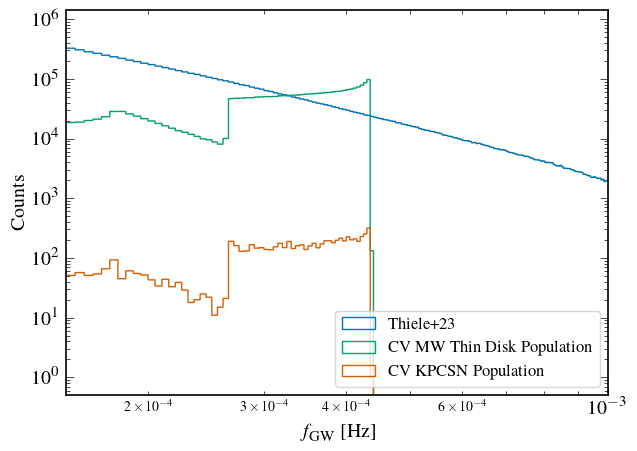

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
dwdcts, _, _ = plt.hist(dwdrsamp['f_gw'], bins=freqs, histtype='step', label='Thiele+23')
thincts, _, _ = plt.hist(cvthincomb[' f_gw[Hz]'], bins=freqs, histtype='step', label='CV MW Thin Disk Population')
kpcsncts, _, _ = plt.hist(kpcsncomb[' f_gw[Hz]'], bins=freqs, histtype='step', label='CV KPCSN Population')
plt.loglog()
ax.set_xlim(1.5e-4, 1e-3)
ax.set_xlabel(r'$f_{\rm GW}$ [Hz]', fontsize='x-large')
ax.set_ylabel('Counts', fontsize='x-large')
ax.tick_params(axis='both', labelsize='x-large')
ax.legend(fontsize='large', loc='lower right')
plt.savefig('')
plt.show()

In [18]:
# LSS occupation fraction by freq
thinrat = thincts / dwdcts
thickrat = thickcts / dwdcts
kpcsnrat = kpcsncts / dwdcts

/tmp/ipykernel_1637147/2729193724.py:2: RuntimeWarning: invalid value encountered in divide
  thinrat = thincts / dwdcts
/tmp/ipykernel_1637147/2729193724.py:3: RuntimeWarning: invalid value encountered in divide
  thickrat = thickcts / dwdcts
/tmp/ipykernel_1637147/2729193724.py:4: RuntimeWarning: invalid value encountered in divide
  kpcsnrat = kpcsncts / dwdcts


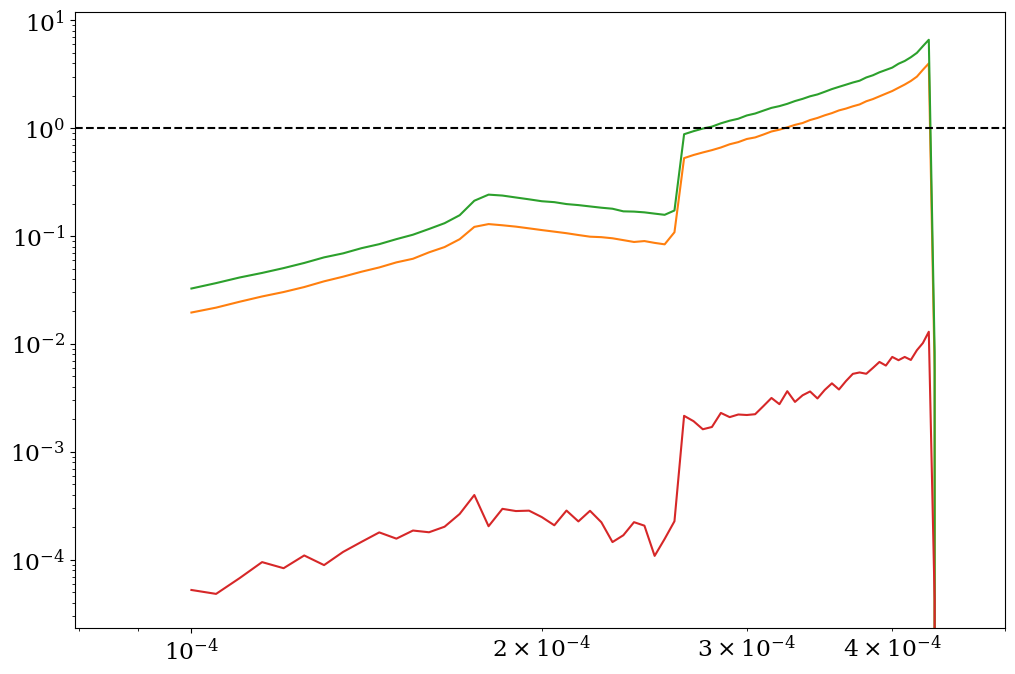

In [62]:
plt.plot(freqs[:-1], thinrat, label='Thin Disk', color='C1')
plt.plot(freqs[:-1], thickrat, label='Thick Disk', color='C2')
plt.plot(freqs[:-1], kpcsnrat, label='KPCSN', color='C3')
plt.loglog()
plt.xlim(None, .5*1e-3)
plt.axhline(y=1, color='k', linestyle='--')

## vestigial

In [7]:
galcentdef = apyco.galactocentric_frame_defaults.get_from_registry('latest')
galcent_sun_dist = galcentdef['parameters']['galcen_distance'].to('kpc').value
galcent_z_sun = galcentdef['parameters']['z_sun'].to('kpc').value

CVdistsun = np.sqrt((cvgxy[' x_galcent[kpc]'] + galcent_sun_dist)**2 + cvgxy[' y_galcent[kpc]']**2 + (cvgxy[' z_galcent[kpc]'] - galcent_z_sun)**2)

(array([6.56400e+03, 1.59260e+04, 2.08840e+04, 3.07220e+04, 4.19130e+04,
        5.47820e+04, 6.99910e+04, 8.76590e+04, 1.08235e+05, 1.31061e+05,
        1.55435e+05, 1.76479e+05, 1.82440e+05, 1.71819e+05, 1.56973e+05,
        1.40447e+05, 1.23802e+05, 1.07028e+05, 9.19830e+04, 7.85300e+04,
        6.67370e+04, 5.68980e+04, 4.70760e+04, 3.65520e+04, 3.09190e+04,
        2.77340e+04, 2.32800e+04, 1.88500e+04, 1.57710e+04, 1.28900e+04,
        1.05420e+04, 8.47100e+03, 6.90500e+03, 5.54300e+03, 4.52800e+03,
        3.67500e+03, 2.95800e+03, 2.34100e+03, 1.93000e+03, 1.56500e+03,
        1.21400e+03, 8.97000e+02, 5.22000e+02, 2.90000e+02, 1.89000e+02,
        1.07000e+02, 6.90000e+01, 5.70000e+01, 2.20000e+01, 1.30000e+01]),
 array([ 0.0364248 ,  0.71257877,  1.38873274,  2.06488671,  2.74104068,
         3.41719465,  4.09334862,  4.76950259,  5.44565656,  6.12181053,
         6.7979645 ,  7.47411847,  8.15027244,  8.82642641,  9.50258038,
        10.17873435, 10.85488832, 11.53104229, 12

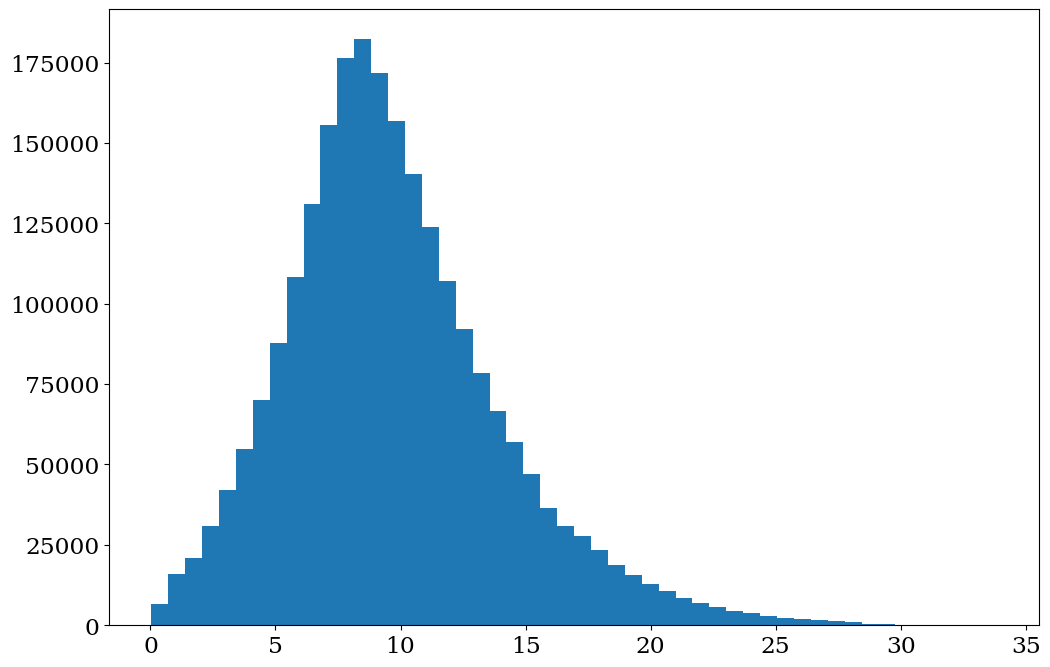

In [8]:
plt.hist(CVdistsun, bins=50)

In [43]:
print(np.min(CVdistsun))
print(np.sum(CVdistsun < 1))

NameError: name 'CVdistsun' is not defined

In [44]:
np.sum(cvgxy[' dist_from_sun[kpc]'] < 1)

np.int64(7352)

In [45]:
cvgxy.shape[0] / dwdrsamp.shape[0]

0.199954067124366

In [46]:
7284/np.sum(dwdrsamp['dist_sun'] < 1)

np.float64(0.3293692064209812)

In [47]:
np.sum(cvgxy[' dist_from_sun[kpc]'] < 1)/np.sum(dwdrsamp['dist_sun'] < 1)

np.float64(0.332444042505087)

In [48]:
kpcsph = (4/3)*np.pi*(1*u.kpc)**3
kpccyl = np.pi*(1*u.kpc)**2*2*u.kpc